In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp

## Nonparametric / distribution-free methods

PSES p-675

In [2]:
data = pd.read_csv('Russian_Demography_1990_2017.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          2380 non-null   int64  
 1   region        2380 non-null   str    
 2   npg           2317 non-null   float64
 3   birth_rate    2317 non-null   float64
 4   death_rate    2315 non-null   float64
 5   gdw           2330 non-null   float64
 6   urbanization  2330 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 130.3 KB


Birth rate -- the number of live births per 1,000 people in a population in a given year.

Death rate -- the number of deaths per 1,000 people in a population in a given year.

NPG (Natural Population Growth) -- the difference between the birth rate and the death rate in a population.

```NPG = birth rate − death rate```

GDW (General Demographic Weight) -- the ratio of the population of non-working age to the population of working age, expressed per 100 people of working age.

```GDW = (Population of non-working age / Population of working age) × 100```

### Test the hypothesis of equality of variances for the birth_rate coefficient for the following periods: (1990–2000), (2001–2010), and (2011–2017) in Moscow and the Moscow Oblast', using nonparametric tests.

In [18]:
data[data['region'].str.lower().str.startswith('mos')]['region'].unique()

<StringArray>
['Moscow', 'Moscow Oblast']
Length: 2, dtype: str

In [26]:
data['year'].max()

np.int64(2017)

In [49]:
periods = [1990, 2001, 2011, 2018]

regions = ['Moscow', 'Moscow Oblast']
moskow_and_oblast = data.loc[data['region'].isin(regions), ['year', 'birth_rate']]

samples = []

for year_range in zip(periods, periods[1:]):
    samples.append(
        moskow_and_oblast[moskow_and_oblast['year'].isin(range(*year_range))]['birth_rate']
    )


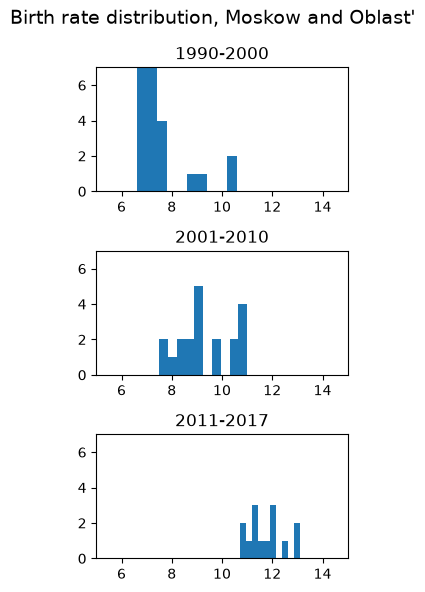

In [91]:
fig, axes = plt.subplots(len(periods)-1, 1, figsize=(3, 6))

for ax, sample, (start, end) in zip(axes, samples, zip(periods, periods[1:])):
    ax.hist(sample)
    ax.set_xlim(5, 15)
    ax.set_ylim(0, 7)
    ax.set_title(f'{start}-{end-1}')

fig.suptitle("Birth rate distribution, Moskow and Oblast'", fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
stats.levene(*samples, center='median', proportiontocut=0.05)

LeveneResult(statistic=np.float64(0.740353629664882), pvalue=np.float64(0.48181244909570126))

In [32]:
stats.fligner(*samples, center='median', proportiontocut=0.05)

FlignerResult(statistic=np.float64(1.5902067606309638), pvalue=np.float64(0.4515345527251121))

### Test the hypothesis of equality of means for the gdw coefficient in Omsk Oblast, the Republic of Karelia, and Ryazan Oblast.

In [41]:
data[data['region'].str.lower().str.startswith(('rya', 'omsk', 'republic of k'))]['region'].unique()

<StringArray>
[ 'Republic of Kalmykia',   'Republic of Karelia',           'Omsk Oblast',
         'Ryazan Oblast', 'Republic of Khakassia']
Length: 5, dtype: str

In [103]:
regions = [ 'Republic of Karelia', 'Omsk Oblast', 'Ryazan Oblast']
samples = [data[data['region'] == region]['gdw'] for region in regions]

In [100]:
stats.describe(samples[0]).minmax

(np.float64(55.66), np.float64(81.13))

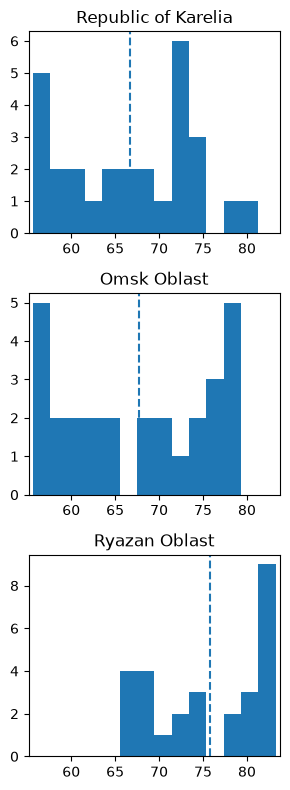

In [109]:
fig, axes = plt.subplots(len(regions), 1, figsize=(3, 8))

x_min = min(sample.min() for sample in samples)
x_max = max(sample.max() for sample in samples)
padding = 0.5

bins = np.linspace(x_min, x_max, 15)

for ax, sample, region in zip(axes, samples, regions):
    ax.hist(sample, bins=bins)
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.axvline(sample.mean(), linestyle='--', label='Mean')
    ax.set_title(region)

plt.tight_layout()
plt.show()

In [45]:
stats.kruskal(*samples, nan_policy='propagate', axis=0, keepdims=False)

KruskalResult(statistic=np.float64(18.53863307313024), pvalue=np.float64(9.427292392282458e-05))

In [112]:
sp.posthoc_dunn(samples, p_adjust='holm')

,1,2,3
1,1.000000,0.580049,0.000212
2,0.580049,1.000000,0.001247
3,0.000212,0.001247,1.000000


##### Непараметрические критерии для двух и более средних

H-критерий Краскела-Уоллиса - scipy.stats.kruskal(*samples, nan_policy='propagate', axis=0, keepdims=False)

- все выборки случайны и независимы
- данные порядковые или непрерывные
- форма распределений выборок должны быть схожими
- равенство дисперсий в группах не обязательна

##### Непараметрический критерий для множественного сравнения

Критерий Данна - posthoc_dunn() из библиотеки scikit-posthocs

##### Непараметрические критерии для дисперсии

Критерий Левена - scipy.stats.levene(*samples, center='median', proportiontocut=0.05)
-    независимые выборки разного размера   
-    нет требований к распределению данных

Критерий Флигнера-Киллина - scipy.stats.fligner(*samples, center='median', proportiontocut=0.05)

- независимые выборки разного размера (больше 5)
- нет требований к распределению данных

Эти критерии для дисперсии можно применять и к нормальным данным вместо критерия Бартлетта.

## Non-parametric tests for comparing independent samples

U-критерий Манна-Уитни -scipy.stats.mannwhitneyu(sample1, sample2, alternative='two-sided')

- независимые выборки
- не менее 3 значений в выборке.
- Лучше всего работает для выборок до 30 значений
- не должно быть совпадающих значений (все числа — разные) или таких совпадений должно быть очень мало (до 10).

Двувыборочный непараметрический критерий Колмогорова-Смирнова - scipy.stats.kstest(rvs, cdf, alternative='two-sided', method='auto')

- Непрерывность данных
- Независимость выборок
- Большие объемы выборок (больше 25)

Тест Андерсона-Дарлинга для k выборок - scipy.stats.anderson_ksamp(samples)

- Непрерывность данных
- Независимость выборок
- Большие объемы выборок
- Выборки должны иметь распределения похожей формы
- Небольшое количество групп